In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.io as pio
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [36]:
import os  
load_path = os.path.join(os.getcwd(), 'data', 'processed', 'CA_cleaned.csv')    
df = pd.read_csv('../data/processed/CA_cleaned.csv')
df.info()  
print(df.shape) 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705412 entries, 0 to 1705411
Data columns (total 41 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Severity               int64  
 1   Start_Time             object 
 2   End_Time               object 
 3   Start_Lat              float64
 4   Start_Lng              float64
 5   Street                 object 
 6   City                   object 
 7   County                 object 
 8   Zipcode                object 
 9   Timezone               object 
 10  Airport_Code           object 
 11  Weather_Timestamp      object 
 12  Temperature(F)         float64
 13  Humidity(%)            float64
 14  Pressure(in)           float64
 15  Visibility(mi)         float64
 16  Wind_Speed(mph)        float64
 17  Amenity                bool   
 18  Bump                   bool   
 19  Crossing               bool   
 20  Give_Way               bool   
 21  Junction               bool   
 22  No_Exit           

In [37]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
# Change object to category
for col in ['Weather_Aggregated', 'road_type', 'Wind_Direction_Mapped']:
    df[col] = df[col].astype('category')

           Number  Procent (%)
Severity                      
1           10077         0.59
2         1415149        82.98
3          267483        15.68
4           12703         0.74


C:\Users\marga\AppData\Local\Temp\ipykernel_31888\1914247993.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




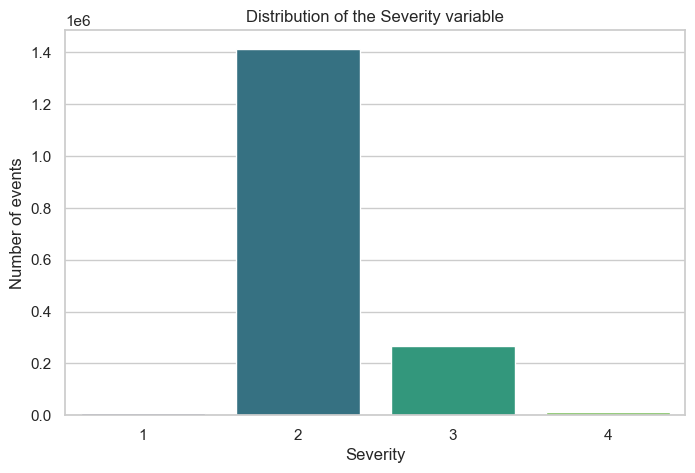

In [38]:
counts = df['Severity'].value_counts().sort_index()
percentages = df['Severity'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'Number': counts, 'Procent (%)': percentages})
print(summary)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity', palette='viridis')
plt.title('Distribution of the Severity variable')
plt.ylabel('Number of events')
plt.show()

            count  mean
Severity               
1           10077  3.39
2         1415149  4.44
3          267483  3.83
4           12703  4.76


<Axes: title={'center': 'Average Duration_log by Severity'}, xlabel='Severity'>

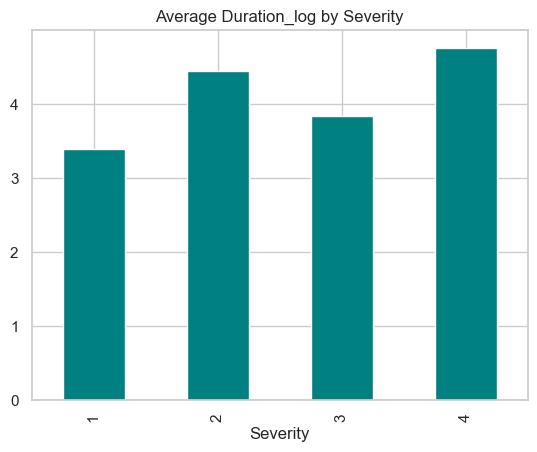

In [39]:
stats = df.groupby('Severity')['Duration_log'].agg(['count', 'mean']).round(2)
print(stats)

# Simple bar chart for average time
stats['mean'].plot(kind='bar', color='teal', title='Average Duration_log by Severity')

Observation: An extreme class imbalance was identified. Class 2 accounts for approximately 83% of the dataset, while classes 1 and 4 are rare (< 1%).

Conclusion: Standard Accuracy is a misleading metric here. Modeling uses **asymmetric cost-matrix class weights** (not SMOTE or undersampling) to penalize under-prediction of severe accidents. Key metrics: Balanced Accuracy, Weighted Kappa (quadratic), and per-class Recall.

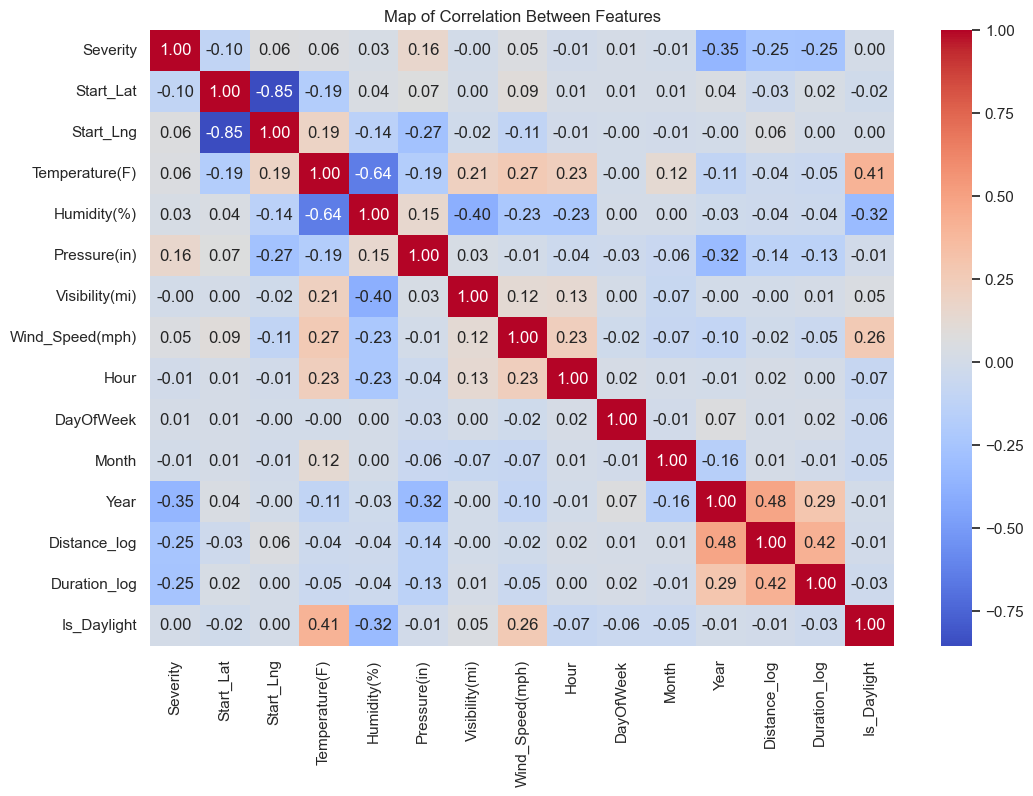

In [40]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Map of Correlation Between Features')
plt.show()

We examined the linear relationships between continuous features (weather, coordinates, time).

Result: High correlation was detected between Start_Lat and Start_Lng, as well as between certain weather parameters (e.g., Temperature vs. Visibility).

Action: These variables were flagged for further verification via the VIF test to avoid redundancy.

Top 10:
 County
Los Angeles       510863
San Bernardino    107531
Orange            106953
San Diego         103044
Alameda            97572
Sacramento         95114
Riverside          86987
Santa Clara        67302
Contra Costa       51109
Kern               36984
Name: count, dtype: int64

Top 10:
 City
Los Angeles       155951
Sacramento         66112
San Diego          55205
San Jose           34418
Riverside          26272
Oakland            23557
San Bernardino     21907
Bakersfield        21218
Anaheim            21133
Long Beach         21009
Name: count, dtype: int64


C:\Users\marga\AppData\Local\Temp\ipykernel_31888\2235131783.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\marga\AppData\Local\Temp\ipykernel_31888\2235131783.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




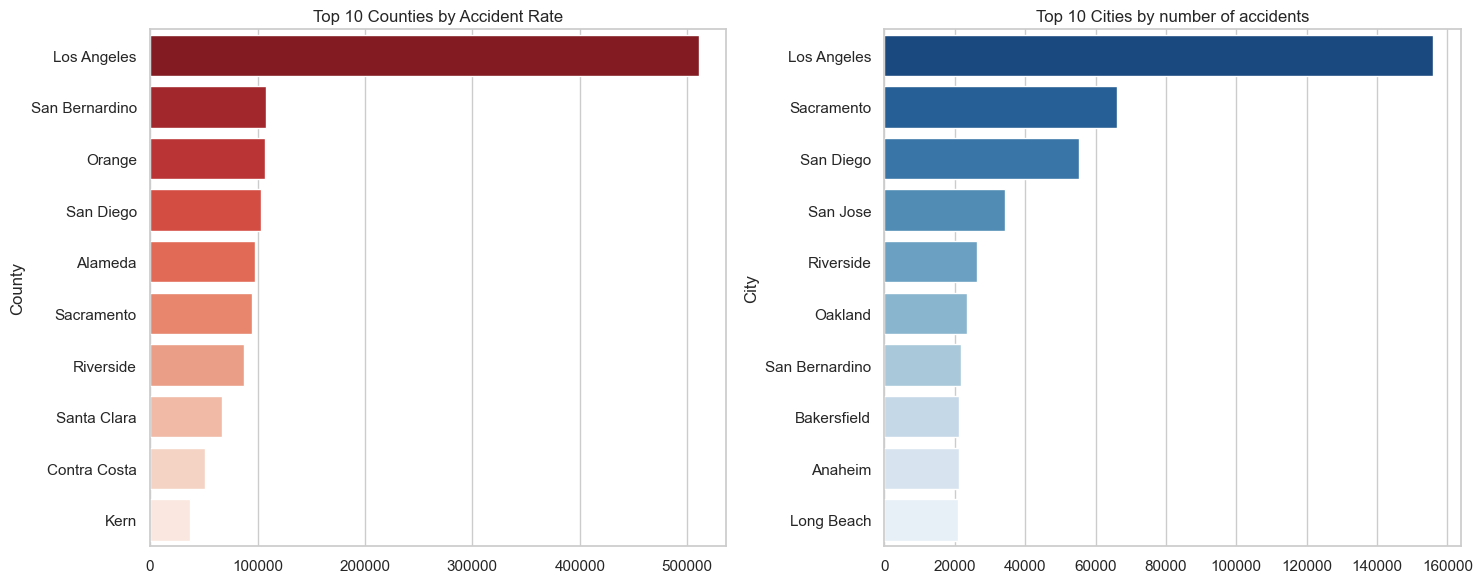

In [41]:
# (Counties)
top_counties = df['County'].value_counts().head(10)

#  (Cities)
top_cities = df['City'].value_counts().head(10)

print("Top 10:\n", top_counties)
print("\nTop 10:\n", top_cities)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=top_counties.values, y=top_counties.index, ax=ax[0], palette='Reds_r')
ax[0].set_title('Top 10 Counties by Accident Rate')

sns.barplot(x=top_cities.values, y=top_cities.index, ax=ax[1], palette='Blues_r')
ax[1].set_title('Top 10 Cities by number of accidents')

plt.tight_layout()
plt.show()

Effect size for 'Temperature(F)': 0.0040


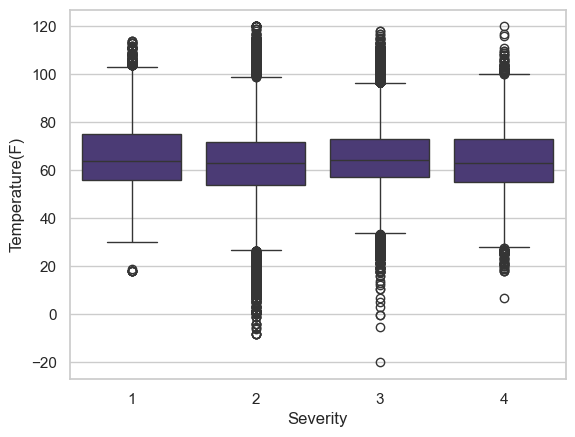

Effect size for 'Distance_log': 0.0914


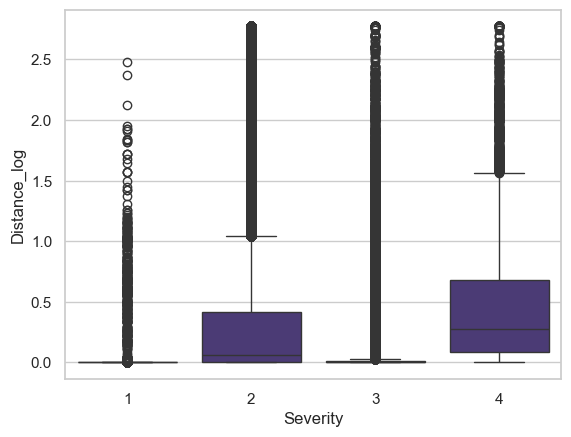

Effect size for 'Visibility(mi)': 0.0002


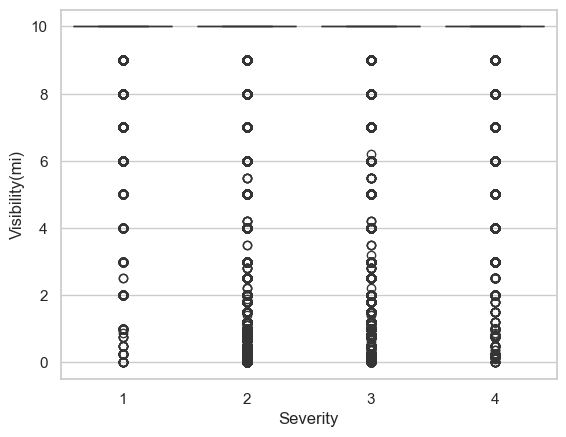

Effect size for 'Humidity(%)': 0.0007


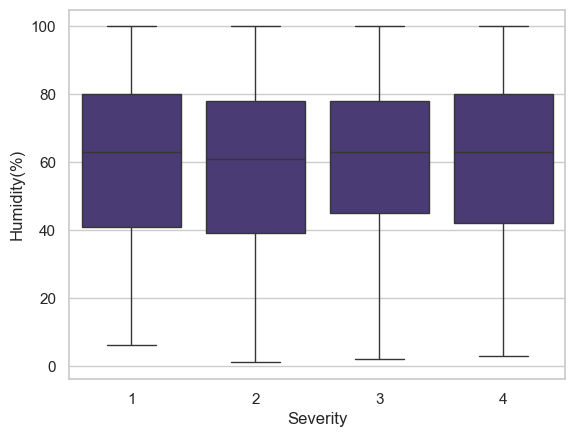

In [42]:
#calculate the effect size
def epsilon_squared(h_statistic, n):
    return h_statistic / ((n**2 - 1) / (n + 1))

numeric_features = ['Temperature(F)', 'Distance_log', 'Visibility(mi)', 'Humidity(%)']
for feature in numeric_features:
    h_stat, _ = kruskal(*[df[feature][df['Severity'] == s] for s in df['Severity'].unique()])
    effect_size = epsilon_squared(h_stat, len(df))
    print(f"Effect size for '{feature}': {effect_size:.4f}")
    
    sns.boxplot(data=df, x='Severity', y=feature)
    plt.show()

Effect size for'Weather_Aggregated' (V Craméra): 0.0386


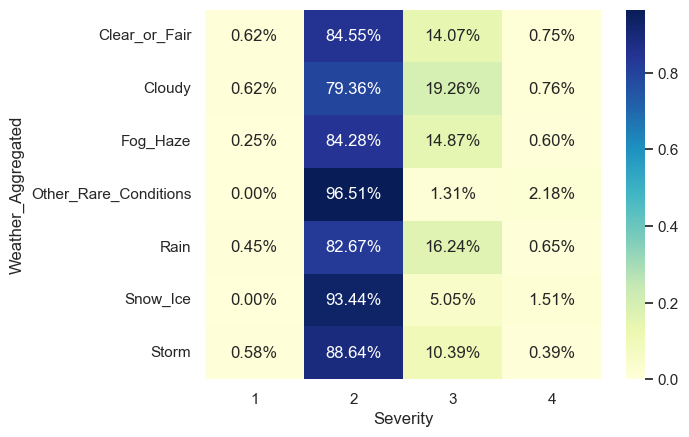

Effect size for'DayOfWeek' (V Craméra): 0.0120


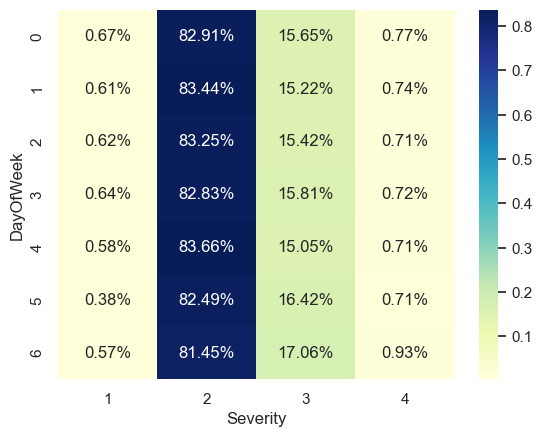

Effect size for'Hour' (V Craméra): 0.0378


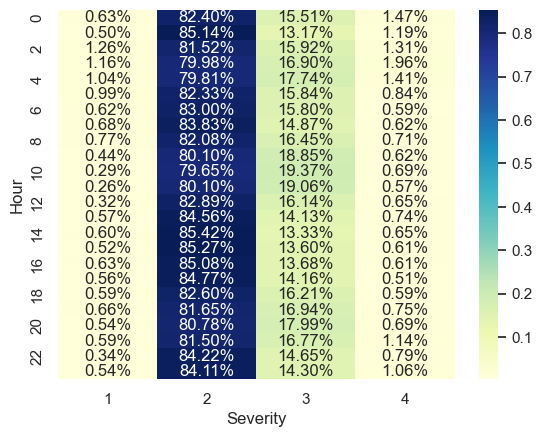

Effect size for'Junction' (V Craméra): 0.0471


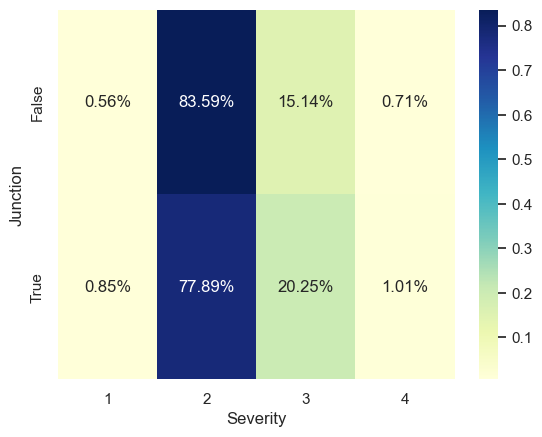

Effect size for'Traffic_Signal' (V Craméra): 0.0644


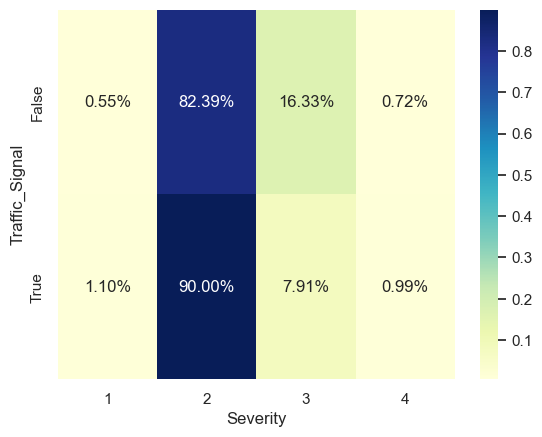

Effect size for'road_type' (V Craméra): 0.1840


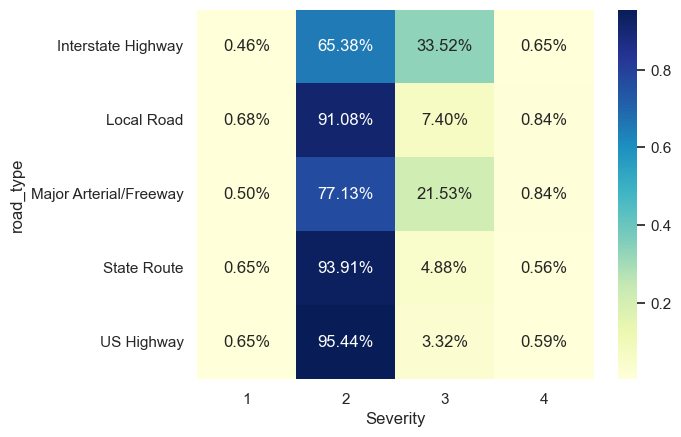

In [43]:
#Function to calculate the effect size
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

categorical_features = ['Weather_Aggregated', 'DayOfWeek', 'Hour', 'Junction', 'Traffic_Signal', 'road_type']
for feature in categorical_features:
    contingency = pd.crosstab(df[feature], df['Severity'])
    effect_size = cramers_v(contingency)
    print(f"Effect size for'{feature}' (V Craméra): {effect_size:.4f}")

    sns.heatmap(contingency.apply(lambda r: r/r.sum(), axis=1), annot=True, fmt=".2%", cmap="YlGnBu")
    plt.show()

In [44]:
X = df.select_dtypes(include=['number', 'bool']).drop(columns=['Severity'], errors='ignore')
X = X.astype(float)

# Columns with a constant value have zero variance and cause a div/0 error
constant_columns = [col for col in X.columns if X[col].nunique() <= 1]
if constant_columns:
    print(f"Usuwam kolumny stałe (zero wariancji): {constant_columns}")
    X = X.drop(columns=constant_columns)

# Adding a constant (intercept)
X['intercept'] = 1.0

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(results := vif_df[vif_df['feature'] != 'intercept'].sort_values('VIF', ascending=False))

Usuwam kolumny stałe (zero wariancji): ['Turning_Loop']
            feature   VIF
1         Start_Lng 10.78
0         Start_Lat 10.00
17  Traffic_Calming  3.18
8              Bump  3.17
3       Humidity(%)  2.19
2    Temperature(F)  2.15
23   is_point_event  2.13
22             Year  1.63
24     Distance_log  1.56
4      Pressure(in)  1.49
9          Crossing  1.35
18   Traffic_Signal  1.30
25     Duration_log  1.30
26      Is_Daylight  1.29
5    Visibility(mi)  1.22
6   Wind_Speed(mph)  1.20
19             Hour  1.13
21            Month  1.11
15          Station  1.10
13          Railway  1.08
16             Stop  1.05
7           Amenity  1.03
11         Junction  1.03
20        DayOfWeek  1.01
10         Give_Way  1.01
12          No_Exit  1.00
14       Roundabout  1.00


The VIF (Variance Inflation Factor) was calculated to precisely remove features that "duplicate" information.

Result: Redundant columns were removed (e.g., Bump was dropped in favor of Traffic_Calming), and high multicollinearity among geographic coordinates was addressed.

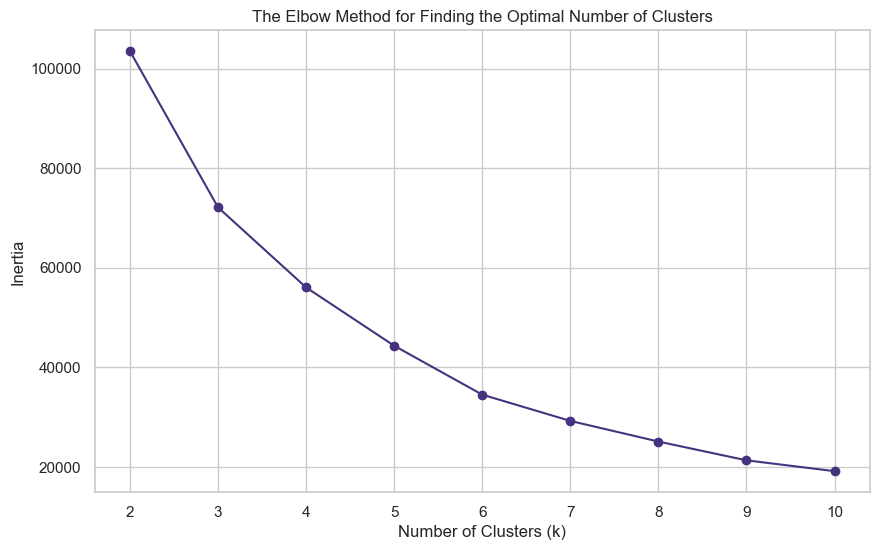

In [45]:
coords = df[['Start_Lat', 'Start_Lng']]

coords_sample = coords.sample(n=100000, random_state=42)

#how the sum of squared distances changes for different numbers of clusters
inertia = []
k_range = range(2, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords_sample)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('The Elbow Method for Finding the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

To simplify the model and improve generalization:

K-Means: Raw geographic coordinates were reduced into 5 distinct macro-regions (Geo_Cluster).

Cluster Analysis: Analysis showed that clusters with the highest average Severity coincide with regions having the highest density of Interstate Highways.

In [46]:
coords = df[['Start_Lat', 'Start_Lng']]

OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

df['Geo_Cluster'] = kmeans.fit_predict(coords)

print(df['Geo_Cluster'].value_counts())

Geo_Cluster
2    618247
0    423733
1    333500
3    212422
4    117510
Name: count, dtype: int64


In [47]:
pio.renderers.default = "notebook"

df_sample = df.sample(n=50000, random_state=42)
df_sample['Geo_Cluster'] = df_sample['Geo_Cluster'].astype('category')

fig = px.scatter_map(
    df_sample,
    lat="Start_Lat",
    lon="Start_Lng",
    color="Geo_Cluster",
    size_max=10,
    zoom=5,
    map_style="carto-positron",
)
fig.show()

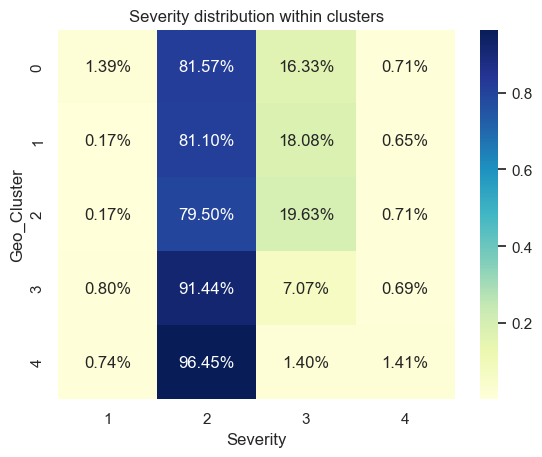

In [48]:
#  Clusters vs Severity
cluster_pivot = pd.crosstab(df['Geo_Cluster'], df['Severity'], normalize='index')
sns.heatmap(cluster_pivot, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title('Severity distribution within clusters')
plt.show()

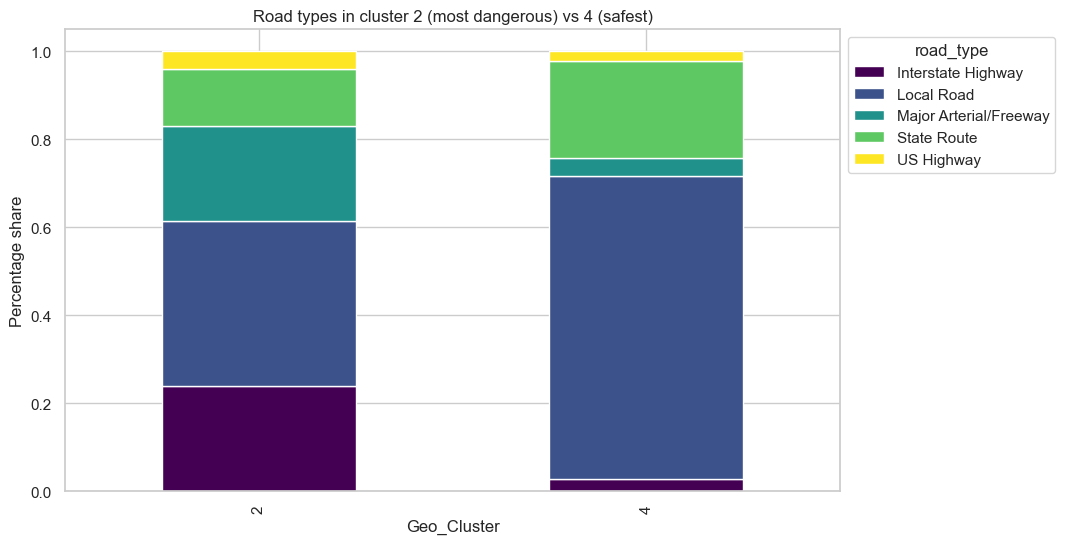

In [49]:
# roads dominate in the most dangerous and safest cluster
cluster_comparison = df[df['Geo_Cluster'].isin([2, 4])]
road_dist = pd.crosstab(cluster_comparison['Geo_Cluster'], cluster_comparison['road_type'], normalize='index')

road_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Road types in cluster 2 (most dangerous) vs 4 (safest)')
plt.ylabel('Percentage share')
plt.legend(title='road_type', bbox_to_anchor=(1, 1))
plt.show()

C:\Users\marga\AppData\Local\Temp\ipykernel_31888\3827996204.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




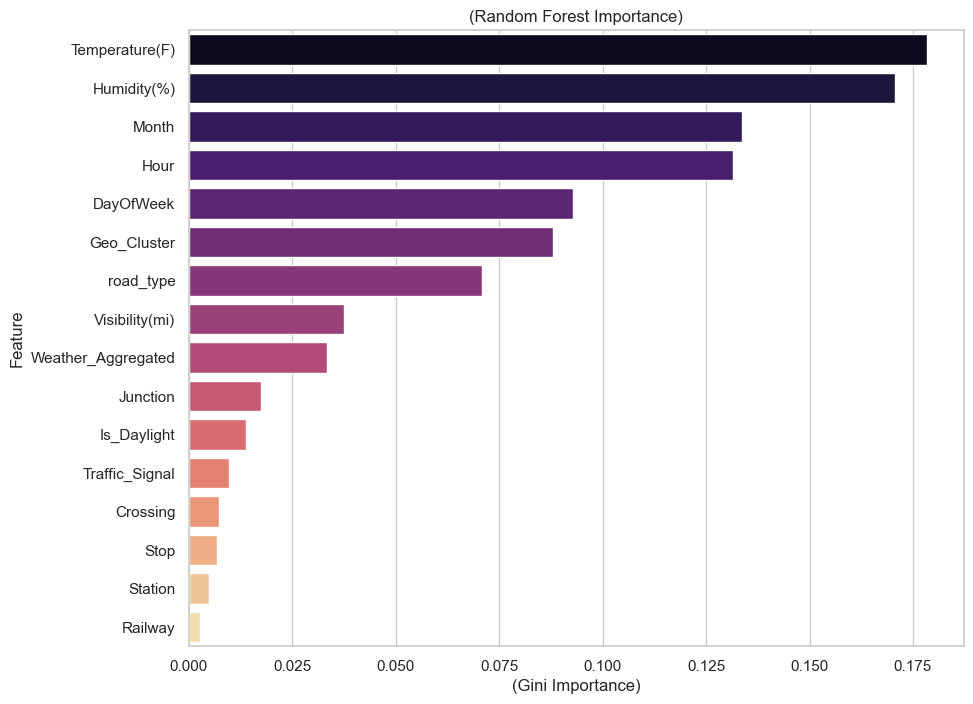

               feature  importance
0       Temperature(F)        0.18
1          Humidity(%)        0.17
5                Month        0.13
3                 Hour        0.13
4            DayOfWeek        0.09
7          Geo_Cluster        0.09
14           road_type        0.07
2       Visibility(mi)        0.04
15  Weather_Aggregated        0.03
8             Junction        0.02
6          Is_Daylight        0.01
9       Traffic_Signal        0.01
10            Crossing        0.01
11                Stop        0.01
12             Station        0.00
13             Railway        0.00


In [50]:
# Features selected after VIF analysis and statistical tests.
#
# Excluded to prevent data leakage:
#   - Distance_log: causal leakage — road extent affected is a *consequence* of severity,
#     not a predictor. Including it would let the model learn a tautology.
#   - Duration_log: temporal leakage — accident duration is only known after the incident
#     ends, so it would not be available at prediction time.
features = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Hour', 'DayOfWeek', 'Month', 'Is_Daylight', 'Geo_Cluster',
    'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway',
    'road_type', 'Weather_Aggregated'
]

X = df[features].copy()
y = df['Severity']

le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'bool', 'category']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Training on a 200k sample
X_sample = X.sample(n=200000, random_state=42)
y_sample = y.loc[X_sample.index]

# class_weight='balanced' corrects for the 83%/17% Severity 2 dominance;
# without it, Gini importance would be biased toward majority-class patterns.
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
model.fit(X_sample, y_sample)

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance, palette='magma')
plt.title('(Random Forest Importance)')
plt.xlabel('(Gini Importance)')
plt.ylabel('Feature')
plt.show()

print(importance)

In [51]:
        
save_path = os.path.join(os.getcwd(), '..', 'data', 'processed', 'CA_cleaned_geo.csv')
df.to_csv(save_path, index=False)
print(f"Saved with Geo_Cluster: {df.shape}")
print(df['Geo_Cluster'].value_counts().sort_index())

Saved with Geo_Cluster: (1705412, 42)
Geo_Cluster
0    423733
1    333500
2    618247
3    212422
4    117510
Name: count, dtype: int64
